In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [15]:
df = pd.read_csv("NepalAgriStats_Cereal.csv")
df.isna().sum()
df.info()
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Columns: 524 entries, DISTRICT_CODE to BW_Y_201314
dtypes: float64(40), int64(483), object(1)
memory usage: 307.2+ KB
['DISTRICT_CODE', 'DISTRICT_NAME', 'PD_P_197980', 'PD_P_198081', 'PD_P_198182', 'PD_P_198283', 'PD_P_198384', 'PD_P_198485', 'PD_P_198586', 'PD_P_198687', 'PD_P_198788', 'PD_P_198889', 'PD_P_199091', 'PD_P_199192', 'PD_P_199293', 'PD_P_199394', 'PD_P_199495', 'PD_P_199596', 'PD_P_199697', 'PD_P_199798', 'PD_P_199899', 'PD_P_199900', 'PD_P_200001', 'PD_P_200102', 'PD_P_200203', 'PD_P_200304', 'PD_P_200405', 'PD_P_200506', 'PD_P_200607', 'PD_P_200708', 'PD_P_200809', 'PD_P_200910', 'PD_P_201011', 'PD_P_201112', 'PD_P_201213', 'PD_P_201314', 'MZ_P_197980', 'MZ_P_198081', 'MZ_P_198182', 'MZ_P_198283', 'MZ_P_198384', 'MZ_P_198485', 'MZ_P_198586', 'MZ_P_198687', 'MZ_P_198788', 'MZ_P_198889', 'MZ_P_199091', 'MZ_P_199192', 'MZ_P_199293', 'MZ_P_199394', 'MZ_P_199495', 'MZ_P_199596', 'MZ_P_199697', 'MZ_P_199798

In [19]:
paddy_col = [col for col in df.columns if col.startswith("PD_P_")]
maize_col = [col for col in df.columns if col.startswith("MZ_P_")]
wheat_col = [col for col in df.columns if col.startswith("WT_P_")]


df['Paddy_Mean'] = df[paddy_col].mean(axis = 1)
df['Maize_Mean'] = df[maize_col].mean(axis = 1)
df['Wheat_Mean'] = df[wheat_col].mean(axis = 1)


df_cluster = df[["DISTRICT_NAME", "Paddy_Mean", "Maize_Mean", "Wheat_Mean"]].copy()

df_cluster.dropna(inplace = True)

print(df_cluster.head())
print(df_cluster.shape)

   DISTRICT_NAME     Paddy_Mean    Maize_Mean    Wheat_Mean
0      Taplejung   11739.613971  18093.086029   2293.029412
1      Panchthar   17841.500000  21409.485294   5331.882353
2           Ilam   28042.983500  39678.676471   6973.382353
3          Jhapa  239727.345588  34176.602941  21705.411765
4  Sankhuwasabha   23531.896412  18196.696441   2157.661765
(75, 4)


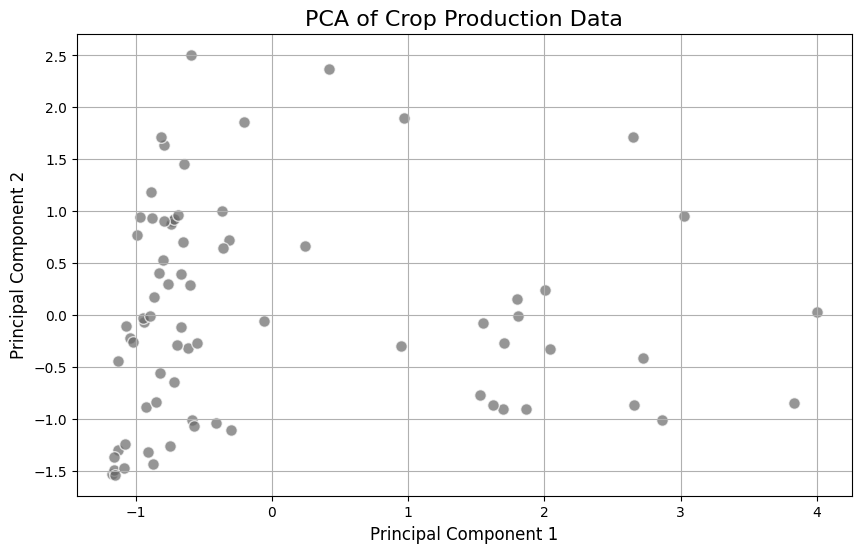

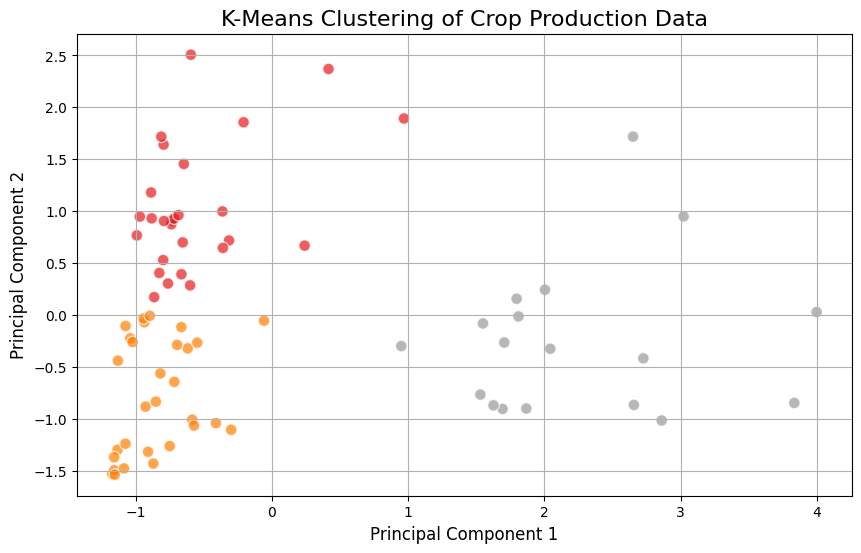

   DISTRICT_NAME     Paddy_Mean    Maize_Mean    Wheat_Mean  Cluster
0      Taplejung   11739.613971  18093.086029   2293.029412        1
1      Panchthar   17841.500000  21409.485294   5331.882353        0
2           Ilam   28042.983500  39678.676471   6973.382353        0
3          Jhapa  239727.345588  34176.602941  21705.411765        2
4  Sankhuwasabha   23531.896412  18196.696441   2157.661765        1
Cluster
1    30
0    27
2    18
Name: count, dtype: int64
            Paddy_Mean    Maize_Mean    Wheat_Mean
Cluster                                           
0         29700.281791  31818.427501   9913.358606
1         10167.962594   9643.163847   5788.319424
2        136506.312510  12366.747631  34901.546029


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


scaler = StandardScaler()


X = df_cluster[["Paddy_Mean", "Maize_Mean", "Wheat_Mean"]].values

X_scaled  =  scaler.fit_transform(X)

# for k in range(2,15):
#     Kmeans=KMeans(n_clusters = k,random_state = 42)
#     Kmeans.fit(X_scaled)
#     silhou_avg = silhouette_score(X_scaled, Kmeans.labels_)
#     print(f"For k = {k}, silhouette score is {silhou_avg:.4f}")
# WE GET THE BEST SCORE FOR K = 3  For k = 2, silhouette score is 0.5526
# For k = 3, silhouette score is 0.4993



pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize = (10,6))

plt.scatter(X_pca[:,0], X_pca[:,1], c = 'dimgray', alpha =0.7, edgecolors = 'w', s=70)
plt.title("PCA of Crop Production Data", fontsize = 16)
plt.xlabel("Principal Component 1", fontsize = 12)
plt.ylabel("Principal Component 2", fontsize = 12)
plt.grid()
plt.show()



model = KMeans(n_clusters = 3, random_state =42)
model.fit(X_pca)
labels = model.labels_


plt.figure(figsize = (10,6))
plt.scatter(X_pca[:,0], X_pca[:,1],c = labels, cmap = 'Set1', alpha = 0.7, edgecolors = 'w', s=70)
plt.title("K-Means Clustering of Crop Production Data", fontsize = 16)
plt.xlabel("Principal Component 1", fontsize = 12)
plt.ylabel("Principal Component 2", fontsize = 12)
plt.grid()
plt.show()
df_cluster['Cluster'] = labels
print(df_cluster.head())
print(df_cluster['Cluster'].value_counts())
cluster_summary = df_cluster.groupby('Cluster')[['Paddy_Mean', 'Maize_Mean', 'Wheat_Mean']].mean()
print(cluster_summary)



